In [3]:
#Task 1: Create a binary image

import cv2
import numpy as np
import matplotlib.pyplot as plt


#Create a binary image with shapes and noise
image = np.zeros((200, 600), dtype=np.uint8)
cv2.circle(image, (100, 100), 40, 255, -1) # Solid circle
cv2.rectangle(image, (200, 60), (280, 140), 255, -1) # Solid rectangle
cv2.circle(image, (400, 100), 40, 255, 2) # Hollow circle
cv2.rectangle(image, (500, 60), (580, 140), 255, 2) # Hollow rectangle

#Add small noise
np.random.seed(0)
for _ in range(1000):
    x, y = np.random.randint(0, 600), np.random.randint(0, 200)
    image[y, x] = 255

In [4]:
#Task 2: Define a structuring element
# Define structuring element (kernel)
kernel = np.ones((5, 5), np.uint8)

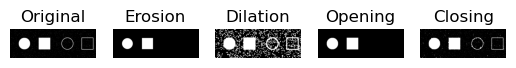

In [9]:
#Apply operations
erosion = cv2.erode(image, kernel, iterations=1)
dilation = cv2.dilate(image, kernel, iterations=1)
opening = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)
closing = cv2.morphologyEx(image, cv2.MORPH_CLOSE, kernel)

#Display
titles = ['Original', 'Erosion', 'Dilation', 'Opening', 'Closing']
images = [image, erosion, dilation, opening, closing]

for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.show()

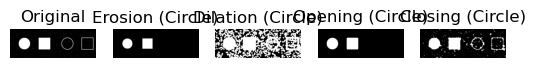

In [13]:
def circular_structuring_element(radius):
    size = 2 * radius + 1
    kernel = np.zeros((size, size), dtype=np.uint8)
    cv2.circle(kernel, (radius, radius), radius, 1, -1)
    return kernel

#Create circular kernel
circle_kernel = circular_structuring_element(5)

#Apply operations
erosion_c = cv2.erode(image, circle_kernel, iterations=1)
dilation_c = cv2.dilate(image, circle_kernel, iterations=1)
opening_c = cv2.morphologyEx(image, cv2.MORPH_OPEN, circle_kernel)
closing_c = cv2.morphologyEx(image, cv2.MORPH_CLOSE, circle_kernel)


titles = ['Original', 'Erosion (Circle)', 'Dilation (Circle)', 'Opening (Circle)', 'Closing (Circle)']
images = [image, erosion_c, dilation_c, opening_c, closing_c]

for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.show()